In [1]:
from src.preprocessing.io.feature_loader import FeatureLoader
from src.common.constants import Constants as consts
import matplotlib.pyplot as plt

feature_loader = FeatureLoader(feat_suffix=consts.wavlm_emb_suffix)
meta, feat = feature_loader.load_data()
meta, feat = feature_loader.sample_data(meta, feat, fraction=0.2)
print(meta.shape, feat.shape)

2026-05-23 19:44:07 | INFO     | FeatureLoader | Using WavLM embeddings suffix
2026-05-23 19:44:07 | INFO     | FeatureLoader | Constructed file path: /Users/mikolajkarapka/Projects/audio-deepfake-detection-uwr/data/collected_data/feature_extracted_wavlm.npy
2026-05-23 19:44:07 | INFO     | FeatureLoader | Constructed file path: /Users/mikolajkarapka/Projects/audio-deepfake-detection-uwr/data/collected_data/feature_extracted.csv
2026-05-23 19:44:07 | INFO     | FeatureLoader | Loading features from /Users/mikolajkarapka/Projects/audio-deepfake-detection-uwr/data/collected_data/feature_extracted.csv
2026-05-23 19:44:07 | INFO     | FeatureLoader | Loading metadata from /Users/mikolajkarapka/Projects/audio-deepfake-detection-uwr/data/collected_data/feature_extracted.csv


(225176, 9) (225176, 768)


In [2]:
meta = meta[meta["anomaly"] == 0]
feat = feat[meta.index]
print(meta.shape, feat.shape)

(104540, 9) (104540, 768)


In [3]:
from umap import UMAP

umap_model = UMAP(
    n_components=3,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    verbose=True,
)

X_umap_3d = umap_model.fit_transform(feat)

UMAP(angular_rp_forest=True, metric='cosine', n_components=3, verbose=True)
Wed May 20 00:31:20 2026 Construct fuzzy simplicial set
Wed May 20 00:31:20 2026 Finding Nearest Neighbors
Wed May 20 00:31:20 2026 Building RP forest with 21 trees
Wed May 20 00:31:24 2026 NN descent for 17 iterations
	 1  /  17
	 2  /  17
	 3  /  17
	 4  /  17
	 5  /  17
	 6  /  17
	Stopping threshold met -- exiting after 6 iterations
Wed May 20 00:31:29 2026 Finished Nearest Neighbor Search
Wed May 20 00:31:30 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Wed May 20 00:31:39 2026 Finished embedding


In [8]:
mask = meta["config"] == "mls-bonafide"
print(mask.sum())

5056


In [16]:
import numpy as np
import plotly.graph_objects as go

mask_np = mask.to_numpy()
x = X_umap_3d[:, 0]
y = X_umap_3d[:, 1]
z = X_umap_3d[:, 2]

fig = go.Figure()

fig.add_trace(
    go.Scatter3d(
        x=x[~mask_np],
        y=y[~mask_np],
        z=z[~mask_np],
        mode="markers",
        marker=dict(size=1, opacity=0.3),
        name="mask=0",
    )
 )

fig.add_trace(
    go.Scatter3d(
        x=x[mask_np],
        y=y[mask_np],
        z=z[mask_np],
        mode="markers",
        marker=dict(size=1, opacity=0.9),
        name="mask=1",
    )
 )

fig.update_layout(
    title="UMAP Projection of WavLM Embeddings (3D)",
    width=800,
    height=800,
 )

fig.show()

In [50]:
from src.preprocessing.io.feature_loader import FeatureLoader
from src.common.constants import Constants as consts

feature_loader = FeatureLoader(feat_suffix=consts.fft_emb_suffix)

meta, feat = feature_loader.load_data()
meta, feat = feature_loader.sample_data(meta, feat, fraction=0.1)
print(meta.shape, feat.shape)

2026-05-23 18:30:29 | INFO     | FeatureLoader | Using FFT embeddings suffix
2026-05-23 18:30:29 | INFO     | FeatureLoader | Constructed file path: /Users/mikolajkarapka/Projects/audio-deepfake-detection-uwr/data/collected_data/feature_extracted_fft.npy
2026-05-23 18:30:29 | INFO     | FeatureLoader | Constructed file path: /Users/mikolajkarapka/Projects/audio-deepfake-detection-uwr/data/collected_data/feature_extracted.csv
2026-05-23 18:30:29 | INFO     | FeatureLoader | Loading features from /Users/mikolajkarapka/Projects/audio-deepfake-detection-uwr/data/collected_data/feature_extracted.csv
2026-05-23 18:30:29 | INFO     | FeatureLoader | Loading metadata from /Users/mikolajkarapka/Projects/audio-deepfake-detection-uwr/data/collected_data/feature_extracted.csv


(112588, 9) (112588, 1026)


In [59]:
from sklearn.preprocessing import Normalizer
from umap import UMAP

norm_feats = Normalizer("l2").fit_transform(feat)

umap_model = UMAP(
    n_components=2,
    n_neighbors=120,  # większe = gładsza struktura
    min_dist=0.6,  # większe = bardziej rozproszone klastry
    metric="euclidean",
    random_state=42,
)

X_umap_2d = umap_model.fit_transform(norm_feats)

/Users/mikolajkarapka/Projects/audio-deepfake-detection-uwr/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [31]:
from sklearn.preprocessing import Normalizer
from umap import UMAP

norm_feats = Normalizer("l2").fit_transform(feat)

umap_model = UMAP(
    n_components=3,
    n_neighbors=120,  # większe = gładsza struktura
    min_dist=0.6,  # większe = bardziej rozproszone klastry
    metric="euclidean",
    random_state=42,
)

X_umap_3d = umap_model.fit_transform(norm_feats)

/Users/mikolajkarapka/Projects/audio-deepfake-detection-uwr/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [34]:
X_umap_3d = X_umap_3d[meta["anomaly"] == 0]

In [10]:
meta_filtered = meta[meta["anomaly"] == 0]
clusters_ids = meta_filtered["config"].astype("category").cat.codes

In [11]:
vocoders_mask = meta_filtered["config"].str.contains("vocoders")
bonafide_mask = meta_filtered["target"] == "bonafide"

In [19]:
print(vocoders_mask.sum(), bonafide_mask.sum())

51297 5056


In [35]:
import numpy as np
import plotly.graph_objects as go

mask_np = bonafide_mask.to_numpy()
x = X_umap_3d[:, 0]
y = X_umap_3d[:, 1]
z = X_umap_3d[:, 2]

fig = go.Figure()

fig.add_trace(
    go.Scatter3d(
        x=x[~mask_np],
        y=y[~mask_np],
        z=z[~mask_np],
        mode="markers",
        marker=dict(size=1, opacity=0.3),
        name="mask=0",
    )
 )

fig.add_trace(
    go.Scatter3d(
        x=x[mask_np],
        y=y[mask_np],
        z=z[mask_np],
        mode="markers",
        marker=dict(size=1, opacity=0.9),
        name="mask=1",
    )
 )

fig.update_layout(
    title="UMAP Projection of WavLM Embeddings (3D)",
    width=800,
    height=800,
 )

fig.show()

In [12]:
bonafide_vocoders_mask = vocoders_mask & bonafide_mask

In [28]:
concat_mask = ~vocoders_mask & ~bonafide_mask

In [112]:
clusters_ids = meta_filtered["config"].map(
    dict(zip(meta_filtered["config"].unique(), range(len(meta_filtered["config"].unique()))))
)

In [52]:
meta_filtered = meta[meta["anomaly"] == 0]

In [53]:
print(len(meta_filtered["config"]))
print(len(X_umap_2d))

104540
104540


/var/folders/1d/mv_j9c7964b105nch0pj7kgh0000gn/T/ipykernel_1911/3283268824.py:13: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored

/var/folders/1d/mv_j9c7964b105nch0pj7kgh0000gn/T/ipykernel_1911/3283268824.py:24: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



([], [])

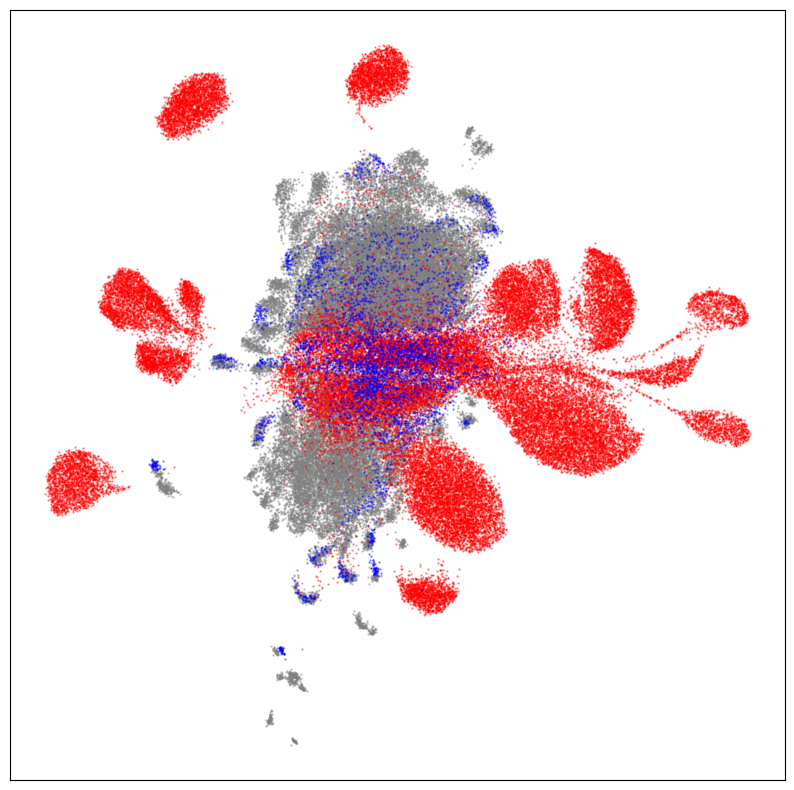

In [51]:
plt.figure(figsize=(10, 10))
plt.scatter(
    X_umap_2d[:, 0][vocoders_mask],
    X_umap_2d[:, 1][vocoders_mask],
    s=0.5,
    alpha=0.4,
    # c=meta["config"].map(
    #     dict(zip(meta["config"].unique(), range(len(meta["config"].unique()))))
    # ),
    # cmap="tab20",
    c="grey",
)
plt.scatter(
    X_umap_2d[:, 0][concat_mask],
    X_umap_2d[:, 1][concat_mask],
    s=0.5,
    alpha=0.4,
    c="red",
    # c=meta["config"].map(
    #     dict(zip(meta["config"].unique(), range(len(meta["config"].unique()))))
    # ),
    cmap="tab20",
)
plt.scatter(
    X_umap_2d[:, 0][bonafide_mask],
    X_umap_2d[:, 1][bonafide_mask],
    s=0.5,
    alpha=0.4,
    c="blue",
    # c=meta["config"].map(
    #     dict(zip(meta["config"].unique(), range(len(meta["config"].unique()))))
    # ),
    cmap="tab20",
)
plt.xticks([])
plt.yticks([])

In [40]:
feature_loader = FeatureLoader(feat_suffix=consts.fft_emb_suffix)

meta, feat = feature_loader.load_data()
meta_20, feat_20 = feature_loader.sample_data(meta, feat, fraction=0.2)
print(meta_20.shape, feat_20.shape)

2026-05-23 18:18:54 | INFO     | FeatureLoader | Using FFT embeddings suffix
2026-05-23 18:18:54 | INFO     | FeatureLoader | Constructed file path: /Users/mikolajkarapka/Projects/audio-deepfake-detection-uwr/data/collected_data/feature_extracted_fft.npy
2026-05-23 18:18:54 | INFO     | FeatureLoader | Constructed file path: /Users/mikolajkarapka/Projects/audio-deepfake-detection-uwr/data/collected_data/feature_extracted.csv
2026-05-23 18:18:54 | INFO     | FeatureLoader | Loading features from /Users/mikolajkarapka/Projects/audio-deepfake-detection-uwr/data/collected_data/feature_extracted.csv
2026-05-23 18:18:54 | INFO     | FeatureLoader | Loading metadata from /Users/mikolajkarapka/Projects/audio-deepfake-detection-uwr/data/collected_data/feature_extracted.csv


(225176, 9) (225176, 1026)


In [59]:
feats_filtered = feat_20[meta_20["anomaly"] == 0]

In [60]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import Normalizer

normalizer = Normalizer("l2")
norm_feats = normalizer.fit_transform(feats_filtered)
tsne = TSNE(n_components=2, random_state=44)
reduced_tsne = tsne.fit_transform(norm_feats)

tsne_X = tsne.fit_transform(norm_feats)

In [61]:
np.save(consts.results_dir / "tsne_2_fft.npy", tsne_X)

In [63]:
filtered_meta = meta_20[meta_20["anomaly"] == 0]

In [64]:
bonafide_mask = filtered_meta["target"] == "bonafide"
tts_mask = filtered_meta["config"].str.contains("tts")
vocoders_mask = filtered_meta["config"].str.contains("vocoders")

In [3]:
uq_map = {
    "mls-tts-chattts": 0,
    "mls-vocoders-bigvgan": 1,
    "mls-tts-xtts": 2,
    "mls-vocoders-hifigan": 3,
    "mls-tts-f5_tts": 4,
    "mls-tts-sparktts": 5,
    "mls-tts-zonos": 6,
    "mls-vocoders-parallel_wavegan": 7,
    "mls-vocoders-melgan": 8,
    "mls-vocoders-style_melgan": 9,
    "mls-vocoders-full_band_melgan": 10,
    "mls-vocoders-vocos": 11,
    "mls-vocoders-bigvsan": 12,
    "mls-vocoders-univnet": 13,
    "mls-vocoders-multi_band_melgan": 14,
    "mls-bonafide": 15,
    "mls-tts-yourtts": 16,
    "mls-tts-bark": 17,
    "mls-tts-fish_speech": 18,
    "mls-tts-cosyvoice": 19,
    "mls-tts-vits": 20,
}

In [4]:
clusters_ids = filtered_meta["config"].map(uq_map)

NameError: name 'filtered_meta' is not defined

/var/folders/1d/mv_j9c7964b105nch0pj7kgh0000gn/T/ipykernel_1911/3022465568.py:2: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



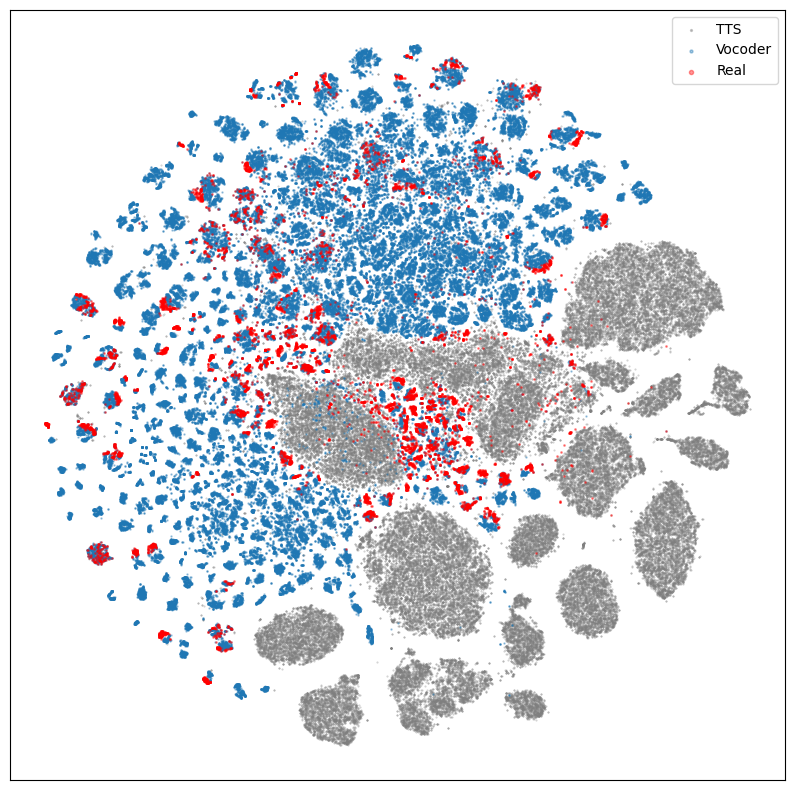

In [66]:
plt.figure(figsize=(10, 10))
plt.scatter(
        tsne_X[:, 0][tts_mask],
        tsne_X[:, 1][tts_mask],
        s=0.2,
        alpha=0.4,
        c="tab:gray",
        # c=clusters,
        cmap="tab20",
    )
plt.scatter(
        tsne_X[:, 0][vocoders_mask],
        tsne_X[:, 1][vocoders_mask ],
        s=0.5,
        alpha=0.4,
        c="tab:blue",
    )
plt.scatter(
        tsne_X[:, 0][bonafide_mask],
        tsne_X[:, 1][bonafide_mask],
        s=1.0,
        alpha=0.4,
        c="red",
    )
plt.xticks([])
plt.yticks([])
plt.legend(["TTS", "Vocoder", "Real"], markerscale=3)
plt.show()

In [2]:
meta_filtered = meta[meta['anomaly'] == 0]

In [6]:
clusters_ids = meta_filtered['config'].map(uq_map)

In [8]:
import numpy as np
tsne_wavlm = np.load(consts.results_dir / "tsne_no_anomalies_20p.npy")

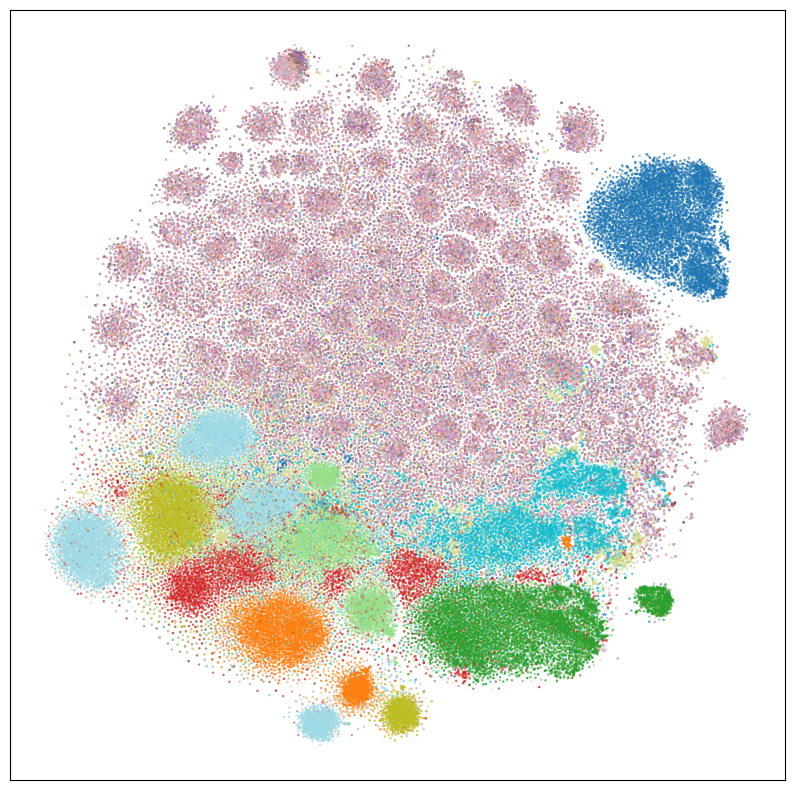

In [9]:
plt.figure(figsize=(10, 10))
plt.scatter(
    tsne_wavlm[:, 0],
    tsne_wavlm[:, 1],
    s=0.5,
    alpha=0.4,
    c=clusters_ids,
    cmap="tab20",
)
plt.xticks([])
plt.yticks([])
plt.show()

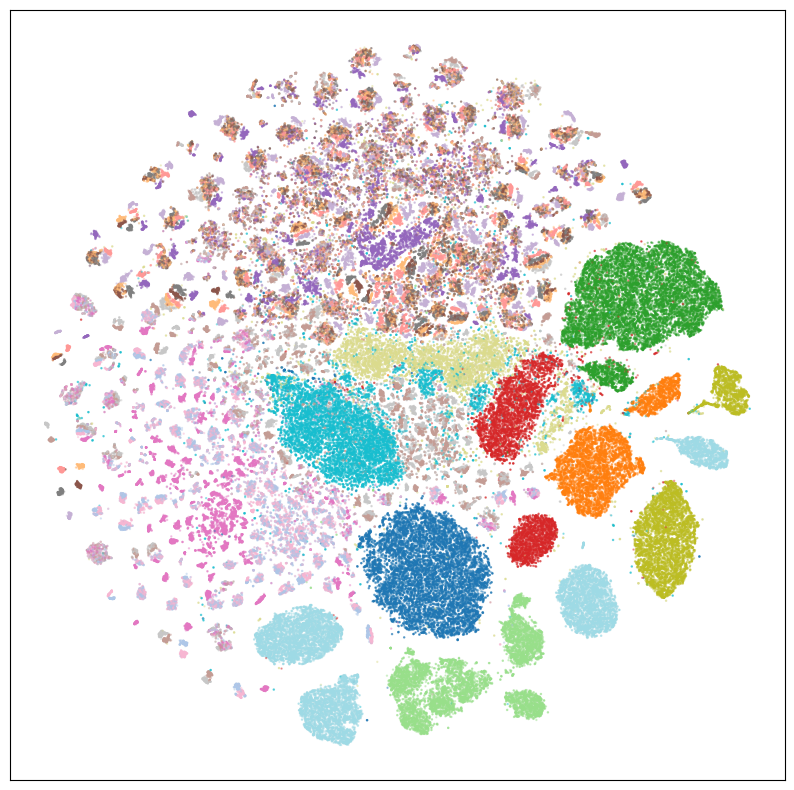

In [73]:
plt.figure(figsize=(10, 10))
plt.scatter(
    tsne_X[:, 0],
    tsne_X[:, 1],
    s=0.5,
    alpha=0.4,
    c=clusters_ids,
    cmap="tab20",
)
plt.xticks([])
plt.yticks([])
plt.show()

In [43]:
tts_mask = meta_filtered['config'].str.contains("tts")
print("Number of tts samples in anomalies:", np.sum(tts_mask))
vocoders_mask = meta_filtered['config'].str.contains("vocoders")
print("Number of vocoder samples in anomalies:", np.sum(vocoders_mask))

clusters_ids = meta_20["config"].map(
    dict(zip(meta_20["config"].unique(), range(len(meta_20["config"].unique()))))
)

Number of tts samples in anomalies: 48187
Number of vocoder samples in anomalies: 51297


In [45]:
meta_filtered = meta_20[meta_20["anomaly"] == 0]
sampled_meta = meta_filtered.sample(frac=0.5, random_state=42)

In [54]:
clusters_ids = meta_filtered["config"].map(uq_map)

In [57]:
print(clusters_ids.unique())

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


In [55]:
colors = plt.cm.tab20(clusters_ids / clusters_ids.max())

/var/folders/1d/mv_j9c7964b105nch0pj7kgh0000gn/T/ipykernel_1911/877853164.py:2: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



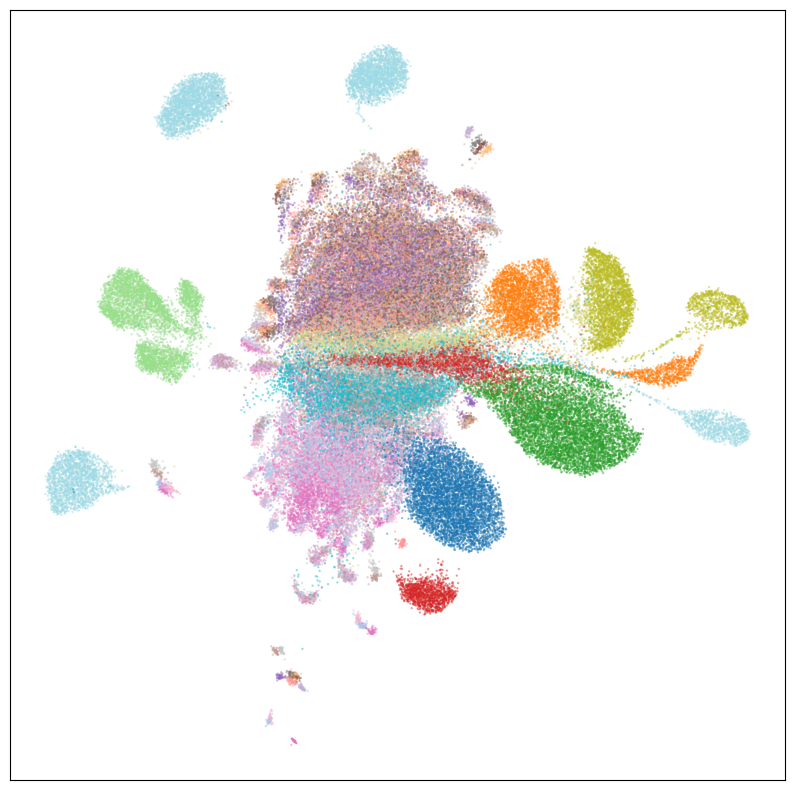

In [58]:
plt.figure(figsize=(10, 10))
plt.scatter(
        X_umap_2d[:, 0],
        X_umap_2d[:, 1],
        s=0.5,
        alpha=0.4,
        c=colors,
        cmap="tab20",
    )
plt.xticks([])
plt.yticks([])
# plt.legend(markerscale=6)
plt.show()